# AtmoSound — Model Training & Evaluation

### Models (from Final Proposal)
1. **Multi-Output Ridge Regression** — closed-form solution, λ sweep, feature ablation
2. **Two-Layer Neural Network** — ReLU, sigmoid output, dropout, batch norm, early stopping
3. **K-Means Clustering** — venue archetypes, elbow method, silhouette score

### Evaluation Metrics
- Mean Squared Error (MSE)
- Cosine Similarity
- Top-K Genre Retrieval Accuracy (K=3, K=5)


## 1. Setup & Load Preprocessed Data

In [87]:
import numpy as np
import pandas as pd
import pickle
import os
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

SEED = 42
np.random.seed(SEED)

data = np.load("pipeline_artifacts/model_ready_data.npz", allow_pickle=True)
X_train = data["X_train"]
y_train = data["y_train"]
X_val   = data["X_val"]
y_val   = data["y_val"]
X_test  = data["X_test"]
y_test  = data["y_test"]
feature_names = list(data["feature_names"])
AUDIO_FEATURES = list(data["audio_feature_names"])

genre_profiles = pd.read_csv("pipeline_artifacts/genre_profiles.csv", index_col=0)

print(f"Train:      {X_train.shape[0]:,} x {X_train.shape[1]}")
print(f"Validation: {X_val.shape[0]:,} x {X_val.shape[1]}")
print(f"Test:       {X_test.shape[0]:,} x {X_test.shape[1]}")
print(f"Targets:    {y_train.shape[1]} audio dimensions")
print(f"Genres:     {genre_profiles.shape[0]}")
print(f"\nAudio features: {AUDIO_FEATURES}")

Train:      2,853 x 279
Validation: 714 x 279
Test:       917 x 279
Targets:    7 audio dimensions
Genres:     112

Audio features: ['danceability', 'energy', 'acousticness', 'valence', 'instrumentalness', 'liveness', 'speechiness']


In [88]:
# setup matplotlib
plt.rcParams.update({
    "figure.facecolor": "#1a1a2e",
    "axes.facecolor": "#16213e",
    "axes.edgecolor": "#e94560",
    "axes.labelcolor": "#e0e0e0",
    "text.color": "#e0e0e0",
    "xtick.color": "#e0e0e0",
    "ytick.color": "#e0e0e0",
    "grid.color": "#2a2a4a",
    "grid.alpha": 0.5,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "figure.titlesize": 16,
    "figure.titleweight": "bold",
    "legend.facecolor": "#16213e",
    "legend.edgecolor": "#e94560",
})
 
PINK = "#e94560"
CYAN = "#0f3460"
TEAL = "#00d2d3"
GOLD = "#f9c74f"
PURPLE = "#a855f7"
GRAY = "#888888"
 
print("Matplotlib configured.")

Matplotlib configured.


## 2. Feature Group Indices (for Ablation)

In [90]:
BOOL_COLS = [
    "good_for_children", "good_for_groups", "good_for_watching_sports",
    "allows_dogs", "live_music", "outdoor_seating", "reservable",
    "serves_beer", "serves_cocktails", "serves_wine", "serves_coffee",
    "serves_breakfast", "serves_brunch", "serves_dinner", "serves_lunch",
    "serves_vegetarian_food", "serves_dessert", "menu_for_children"
]

bool_idx = [i for i, c in enumerate(feature_names) if c in BOOL_COLS]
text_idx = [i for i, c in enumerate(feature_names) if c.startswith("text_svd_")]
cat_idx  = [i for i, c in enumerate(feature_names)
            if c.startswith("neigh_") or c.startswith("ptype_")
            or c in ["price_level_encoded", "price_level_missing", "rating"]]

print(f"Boolean features:     {len(bool_idx)} dims  (indices {bool_idx[0]}..{bool_idx[-1]})")
print(f"Text SVD features:    {len(text_idx)} dims  (indices {text_idx[0]}..{text_idx[-1]})")
print(f"Categorical features: {len(cat_idx)} dims")
print(f"All features:         {len(feature_names)} dims")

Boolean features:     18 dims  (indices 3..20)
Text SVD features:    50 dims  (indices 229..278)
Categorical features: 211 dims
All features:         279 dims


## 3. Evaluation Metrics (From Scratch)

All three metrics from the proposal:
1. **MSE** — Mean Squared Error averaged over all samples and all 7 dimensions. Averaged over all 7 output dimensions
2. **Cosine Similarity** — Mean cosine similarity between true and predicted audio profiles. Profile shape match independent of magnitude
3. **Top-K Genre Retrieval Accuracy** — For each sample, find the K nearest genre centroids to the predicted
    profile and check if the nearest genre to the TRUE profile is among them. Does the predicted profile land near the correct genre?


In [92]:
def compute_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def compute_cosine_similarity(y_true, y_pred):
    dot_products = np.sum(y_true * y_pred, axis=1)
    norms_true = np.linalg.norm(y_true, axis=1)
    norms_pred = np.linalg.norm(y_pred, axis=1)
    cos_sim = dot_products / (norms_true * norms_pred + 1e-8)
    return np.mean(cos_sim)

def compute_topk_accuracy(y_true, y_pred, genre_centroids, k=5):
    n = y_true.shape[0]
    hits = 0
    for i in range(n):
        # True genre = nearest centroid to y_true[i]
        true_dists = np.linalg.norm(genre_centroids - y_true[i], axis=1)
        true_genre_idx = np.argmin(true_dists)

        # Predicted top-K = K nearest centroids to y_pred[i]
        pred_dists = np.linalg.norm(genre_centroids - y_pred[i], axis=1)
        topk_indices = np.argsort(pred_dists)[:k]

        if true_genre_idx in topk_indices:
            hits += 1
    return hits / n

def evaluate_model(y_true, y_pred, genre_centroids, label="Model"):
    mse = compute_mse(y_true, y_pred)
    cos = compute_cosine_similarity(y_true, y_pred)
    acc3 = compute_topk_accuracy(y_true, y_pred, genre_centroids, k=3)
    acc5 = compute_topk_accuracy(y_true, y_pred, genre_centroids, k=5)
    print(f"  {label}")
    print(f"    MSE:              {mse:.6f}")
    print(f"    Cosine Similarity:{cos:.6f}")
    print(f"    Top-3 Accuracy:   {acc3:.4f} ({acc3*100:.1f}%)")
    print(f"    Top-5 Accuracy:   {acc5:.4f} ({acc5*100:.1f}%)")
    return {"mse": mse, "cosine_sim": cos, "top3_acc": acc3, "top5_acc": acc5}

genre_centroids = genre_profiles.values
print(f"Genre centroids: {genre_centroids.shape}")
print("Evaluation functions defined.")

Genre centroids: (112, 7)
Evaluation functions defined.


## 4. Baselines

In [94]:
# Mean-prediction baseline
y_mean_pred = np.tile(y_train.mean(axis=0), (X_test.shape[0], 1))
print("=" * 60)
baseline_mean = evaluate_model(y_test, y_mean_pred, genre_centroids, "Mean-Prediction Baseline")

# Random-genre baseline
rng = np.random.RandomState(SEED)
rand_idx = rng.choice(len(genre_centroids), size=X_test.shape[0])
y_random_pred = genre_centroids[rand_idx]
print()
baseline_rand = evaluate_model(y_test, y_random_pred, genre_centroids, "Random-Genre Baseline")
print("=" * 60)
print(f"\nModels must beat MSE < {baseline_mean['mse']:.6f}")

  Mean-Prediction Baseline
    MSE:              0.004124
    Cosine Similarity:0.987393
    Top-3 Accuracy:   0.2923 (29.2%)
    Top-5 Accuracy:   0.3631 (36.3%)

  Random-Genre Baseline
    MSE:              0.031912
    Cosine Similarity:0.916429
    Top-3 Accuracy:   0.0382 (3.8%)
    Top-5 Accuracy:   0.0491 (4.9%)

Models must beat MSE < 0.004124


## 5. Model 1: Multi-Output Ridge Regression

Closed-form solution: $W^* = (X^T X + \lambda I)^{-1} X^T Y$

Sweep $\lambda \in \{0.001, 0.01, 0.1, 1, 10, 100\}$, select by lowest validation MSE. Adds bias column internally.


In [96]:
class MultiOutputRidgeRegression:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.W = None  # (d+1, 7) weight matrix including bias

    def fit(self, X, Y):
        n, d = X.shape
        # Add bias column
        X_b = np.hstack([X, np.ones((n, 1))])
        # Closed-form solution
        XtX = X_b.T @ X_b
        reg = self.alpha * np.eye(XtX.shape[0])
        reg[-1, -1] = 0  # Don't regularize bias
        self.W = np.linalg.solve(XtX + reg, X_b.T @ Y)
        return self

    def predict(self, X):
        n = X.shape[0]
        X_b = np.hstack([X, np.ones((n, 1))])
        return X_b @ self.W

    def get_weights(self):
        #Return weight matrix without bias row
        return self.W[:-1, :]

    def get_bias(self):
        return self.W[-1, :]

print("MultiOutputRidgeRegression defined.")

MultiOutputRidgeRegression defined.


### 5.1 Hyperparameter Sweep (λ)

In [98]:
LAMBDAS = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

print("Ridge Regression — Lambda Sweep")
print("=" * 65)
print(f"{'Lambda':>10s}  {'Train MSE':>10s}  {'Val MSE':>10s}  {'Val CosSim':>10s}  {'Val Acc@5':>10s}")
print("-" * 65)

ridge_results = {}
best_ridge_mse = float("inf")
best_ridge_lambda = None
best_ridge_model = None

for lam in LAMBDAS:
    model = MultiOutputRidgeRegression(alpha=lam)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    train_mse = compute_mse(y_train, y_train_pred)
    val_mse = compute_mse(y_val, y_val_pred)
    val_cos = compute_cosine_similarity(y_val, y_val_pred)
    val_acc5 = compute_topk_accuracy(y_val, y_val_pred, genre_centroids, k=5)

    ridge_results[lam] = {
        "train_mse": train_mse, "val_mse": val_mse,
        "val_cos": val_cos, "val_acc5": val_acc5, "model": model
    }

    marker = ""
    if val_mse < best_ridge_mse:
        best_ridge_mse = val_mse
        best_ridge_lambda = lam
        best_ridge_model = model
        marker = " <-- best"

    print(f"{lam:10.3f}  {train_mse:10.6f}  {val_mse:10.6f}  {val_cos:10.6f}  {val_acc5:10.4f}{marker}")

print("-" * 65)
print(f"Best λ = {best_ridge_lambda} (Val MSE = {best_ridge_mse:.6f})")

Ridge Regression — Lambda Sweep
    Lambda   Train MSE     Val MSE  Val CosSim   Val Acc@5
-----------------------------------------------------------------
     0.001    0.000013    0.000239    0.999275      0.9776 <-- best
     0.010    0.000013    0.000209    0.999364      0.9776 <-- best
     0.100    0.000017    0.000140    0.999579      0.9888 <-- best
     1.000    0.000037    0.000142    0.999576      0.9916
    10.000    0.000232    0.000327    0.999012      0.9678
   100.000    0.001065    0.001100    0.996629      0.8501
-----------------------------------------------------------------
Best λ = 0.1 (Val MSE = 0.000140)


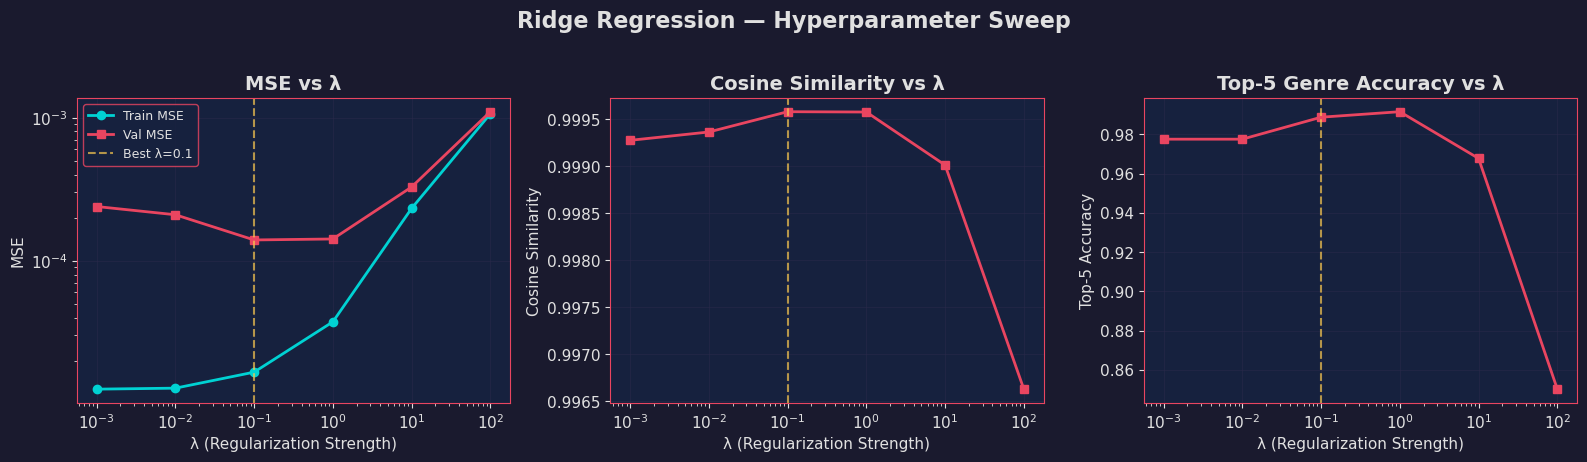

In [99]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
 
lambdas = list(ridge_results.keys())
train_mses = [ridge_results[l]["train_mse"] for l in lambdas]
val_mses = [ridge_results[l]["val_mse"] for l in lambdas]
val_cossims = [ridge_results[l]["val_cos"] for l in lambdas]
val_acc5s = [ridge_results[l]["val_acc5"] for l in lambdas]
 
# MSE vs Lambda
axes[0].plot(lambdas, train_mses, "o-", color=TEAL, label="Train MSE", linewidth=2, markersize=6)
axes[0].plot(lambdas, val_mses, "s-", color=PINK, label="Val MSE", linewidth=2, markersize=6)
axes[0].axvline(x=best_ridge_lambda, color=GOLD, linestyle="--", alpha=0.7, label=f"Best λ={best_ridge_lambda}")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("λ (Regularization Strength)")
axes[0].set_ylabel("MSE")
axes[0].set_title("MSE vs λ")
axes[0].legend(fontsize=9)
axes[0].grid(True)
 
# Cosine Similarity vs Lambda
axes[1].plot(lambdas, val_cossims, "s-", color=PINK, linewidth=2, markersize=6)
axes[1].axvline(x=best_ridge_lambda, color=GOLD, linestyle="--", alpha=0.7)
axes[1].set_xscale("log")
axes[1].set_xlabel("λ (Regularization Strength)")
axes[1].set_ylabel("Cosine Similarity")
axes[1].set_title("Cosine Similarity vs λ")
axes[1].grid(True)
 
# Top-5 Accuracy vs Lambda
axes[2].plot(lambdas, val_acc5s, "s-", color=PINK, linewidth=2, markersize=6)
axes[2].axvline(x=best_ridge_lambda, color=GOLD, linestyle="--", alpha=0.7)
axes[2].set_xscale("log")
axes[2].set_xlabel("λ (Regularization Strength)")
axes[2].set_ylabel("Top-5 Accuracy")
axes[2].set_title("Top-5 Genre Accuracy vs λ")
axes[2].grid(True)
 
fig.suptitle("Ridge Regression — Hyperparameter Sweep", y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Feature Ablation Study

In [101]:
ABLATION_CONFIGS = {
    "Booleans only":    bool_idx,
    "Text SVD only":    text_idx,
    "Categorical only": cat_idx,
    "Full vector":      list(range(X_train.shape[1])),
}
print(f"Feature Ablation (Ridge, λ = {best_ridge_lambda})")
print("=" * 65)
print(f"{'Config':>20s}  {'Dims':>5s}  {'Val MSE':>10s}  {'Val CosSim':>10s}  {'Val Acc@5':>10s}")
print("-" * 65)

ablation_results = {}
for name, idx in ABLATION_CONFIGS.items():
    model = MultiOutputRidgeRegression(alpha=best_ridge_lambda)
    model.fit(X_train[:, idx], y_train)
    y_val_pred = model.predict(X_val[:, idx])

    val_mse = compute_mse(y_val, y_val_pred)
    val_cos = compute_cosine_similarity(y_val, y_val_pred)
    val_acc5 = compute_topk_accuracy(y_val, y_val_pred, genre_centroids, k=5)

    ablation_results[name] = {"val_mse": val_mse, "val_cos": val_cos, "val_acc5": val_acc5}
    print(f"{name:>20s}  {len(idx):5d}  {val_mse:10.6f}  {val_cos:10.6f}  {val_acc5:10.4f}")

print("-" * 65)

Feature Ablation (Ridge, λ = 0.1)
              Config   Dims     Val MSE  Val CosSim   Val Acc@5
-----------------------------------------------------------------
       Booleans only     18    0.002827    0.991351      0.7409
       Text SVD only     50    0.002432    0.992567      0.7073
    Categorical only    211    0.000149    0.999549      0.9860
         Full vector    279    0.000140    0.999579      0.9888
-----------------------------------------------------------------


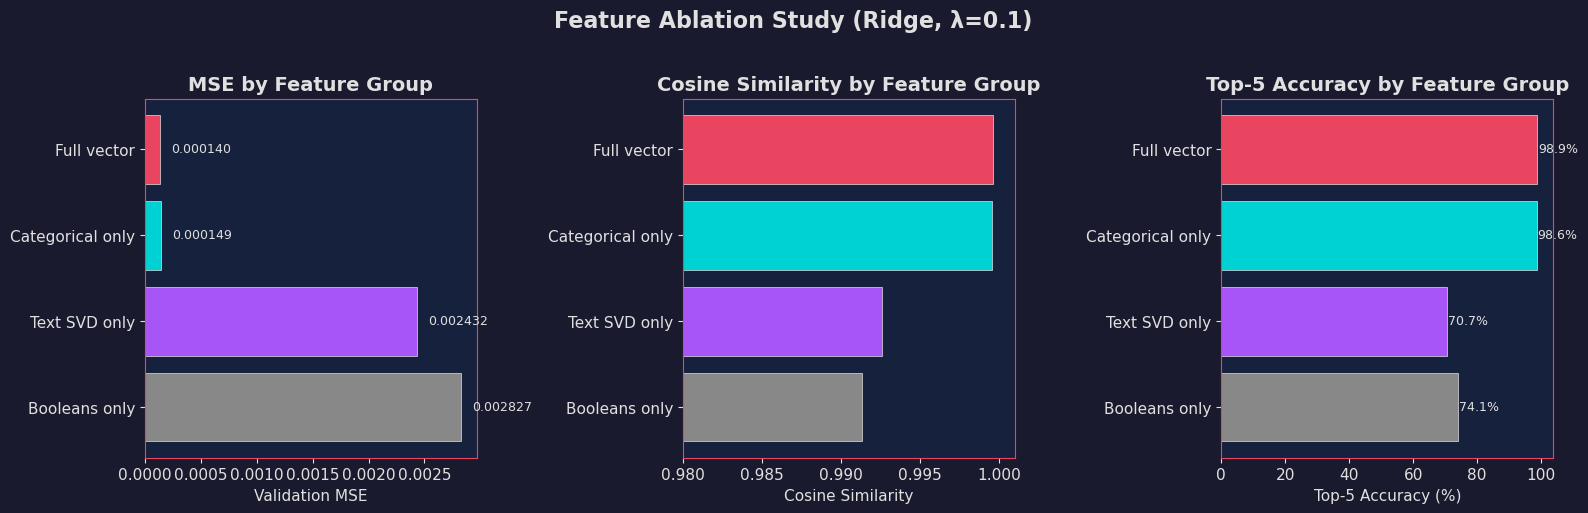

In [102]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
configs = list(ablation_results.keys())
colors = [GRAY, PURPLE, TEAL, PINK]
 
# MSE
mse_vals = [ablation_results[c]["val_mse"] for c in configs]
bars = axes[0].barh(configs, mse_vals, color=colors, edgecolor="#e0e0e0", linewidth=0.5)
axes[0].set_xlabel("Validation MSE")
axes[0].set_title("MSE by Feature Group")
for bar, val in zip(bars, mse_vals):
    axes[0].text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
                 f"{val:.6f}", va="center", fontsize=9, color="#e0e0e0")
 
# Cosine Similarity
cos_vals = [ablation_results[c]["val_cos"] for c in configs]
bars = axes[1].barh(configs, cos_vals, color=colors, edgecolor="#e0e0e0", linewidth=0.5)
axes[1].set_xlabel("Cosine Similarity")
axes[1].set_title("Cosine Similarity by Feature Group")
axes[1].set_xlim(0.98, 1.001)
 
# Top-5 Accuracy
acc_vals = [ablation_results[c]["val_acc5"] for c in configs]
bars = axes[2].barh(configs, [v * 100 for v in acc_vals], color=colors, edgecolor="#e0e0e0", linewidth=0.5)
axes[2].set_xlabel("Top-5 Accuracy (%)")
axes[2].set_title("Top-5 Accuracy by Feature Group")
for bar, val in zip(bars, acc_vals):
    axes[2].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f"{val*100:.1f}%", va="center", fontsize=9, color="#e0e0e0")
 
fig.suptitle("Feature Ablation Study (Ridge, λ=0.1)", y=1.02)
plt.tight_layout()
plt.show()

### 5.3 Ridge: Test Set Evaluation

In [104]:
print("Ridge Regression — Final Test Evaluation")
print("=" * 60)
y_test_pred_ridge = best_ridge_model.predict(X_test)
ridge_test = evaluate_model(y_test, y_test_pred_ridge, genre_centroids, f"Ridge (λ={best_ridge_lambda})")

Ridge Regression — Final Test Evaluation
  Ridge (λ=0.1)
    MSE:              0.000281
    Cosine Similarity:0.999140
    Top-3 Accuracy:   0.9804 (98.0%)
    Top-5 Accuracy:   0.9858 (98.6%)


### 5.4 Ridge: Feature Importance

Top features per audio dimension (highest absolute weight).


In [106]:
W = best_ridge_model.get_weights()  # (d, 7)
print("Top 10 Most Important Features Per Audio Dimension:")
print("=" * 70)

for j, feat_name in enumerate(AUDIO_FEATURES):
    abs_w = np.abs(W[:, j])
    top10 = np.argsort(abs_w)[-10:][::-1]
    print(f"\n  {feat_name}:")
    for rank, idx in enumerate(top10):
        print(f"    {rank+1:2d}. {feature_names[idx]:35s}  w = {W[idx, j]:+.4f}")

Top 10 Most Important Features Per Audio Dimension:

  danceability:
     1. ptype_jewelry_store                  w = -0.1238
     2. ptype_book_store                     w = -0.0970
     3. ptype_fitness_center                 w = +0.0893
     4. price_level_encoded                  w = -0.0825
     5. ptype_shoe_store                     w = +0.0737
     6. ptype_yoga_studio                    w = -0.0718
     7. ptype_womens_clothing_store          w = +0.0709
     8. ptype_clothing_store                 w = +0.0708
     9. ptype_gym                            w = +0.0683
    10. ptype_tea_house                      w = -0.0615

  energy:
     1. ptype_jewelry_store                  w = -0.2726
     2. ptype_yoga_studio                    w = -0.2399
     3. ptype_tea_house                      w = -0.2192
     4. ptype_book_store                     w = -0.2088
     5. ptype_bakery                         w = -0.1556
     6. ptype_home_goods_store               w = -0.1309
     7. 

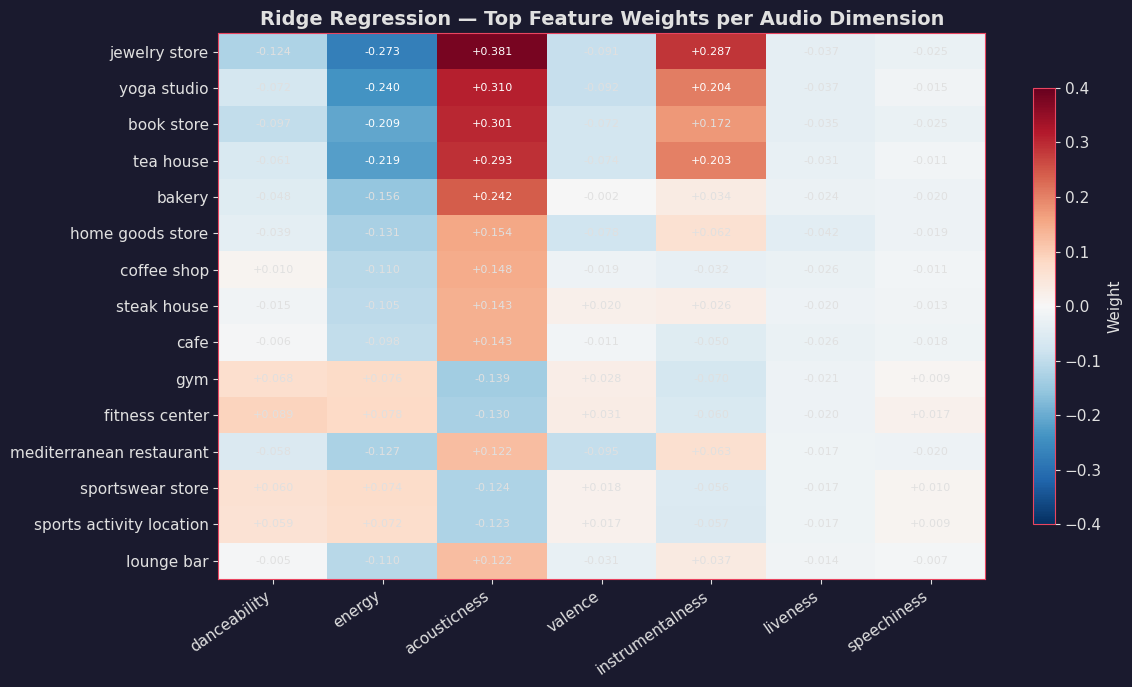

In [107]:
W = best_ridge_model.get_weights()
 
# Get the top 15 features by max absolute weight across any dimension
max_abs = np.max(np.abs(W), axis=1)
top15_idx = np.argsort(max_abs)[-15:][::-1]
top15_names = [feature_names[i] for i in top15_idx]
W_subset = W[top15_idx, :]
 
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(W_subset, cmap="RdBu_r", aspect="auto", vmin=-0.4, vmax=0.4)
 
ax.set_xticks(range(len(AUDIO_FEATURES)))
ax.set_xticklabels(AUDIO_FEATURES, rotation=35, ha="right")
ax.set_yticks(range(len(top15_names)))
ax.set_yticklabels([n.replace("ptype_", "").replace("_", " ") for n in top15_names])
 
for i in range(W_subset.shape[0]):
    for j in range(W_subset.shape[1]):
        val = W_subset[i, j]
        text_color = "white" if abs(val) > 0.2 else "#e0e0e0"
        ax.text(j, i, f"{val:+.3f}", ha="center", va="center",
                fontsize=8, color=text_color)
 
cbar = plt.colorbar(im, ax=ax, shrink=0.8, label="Weight")
cbar.ax.yaxis.label.set_color("#e0e0e0")
cbar.ax.tick_params(colors="#e0e0e0")
 
ax.set_title("Ridge Regression — Top Feature Weights per Audio Dimension")
plt.tight_layout()
plt.show()

## 6. Model 2: Two-Layer Neural Network

Two-layer neural network for multi-output regression.
Architecture: Input(d) → Hidden1(128, ReLU) → Hidden2(64, ReLU) → Output(7, sigmoid)

Features: dropout, batch normalization, He initialization, gradient clipping.
From scratch with NumPy: forward pass, backpropagation, mini-batch SGD,
dropout, batch normalization, and early stopping.

Grid search: lr ∈ {0.001, 0.005, 0.01}, batch_size ∈ {32, 64, 128}, dropout ∈ {0.0, 0.2}


In [109]:
class NeuralNetwork:
    def __init__(self, input_dim, hidden1=128, hidden2=64, output_dim=7,
                 lr=0.001, dropout_rate=0.0, use_batch_norm=False, seed=42):
        self.lr = lr
        self.dropout_rate = dropout_rate
        self.use_batch_norm = use_batch_norm
        self.rng = np.random.RandomState(seed)

        # He initialization for ReLU layers
        self.W1 = self.rng.randn(input_dim, hidden1) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden1))
        self.W2 = self.rng.randn(hidden1, hidden2) * np.sqrt(2.0 / hidden1)
        self.b2 = np.zeros((1, hidden2))
        self.W3 = self.rng.randn(hidden2, output_dim) * np.sqrt(2.0 / hidden2)
        self.b3 = np.zeros((1, output_dim))

        # Batch norm parameters (learnable scale and shift)
        if self.use_batch_norm:
            self.gamma1 = np.ones((1, hidden1))
            self.beta1 = np.zeros((1, hidden1))
            self.gamma2 = np.ones((1, hidden2))
            self.beta2 = np.zeros((1, hidden2))
            # Running stats for inference
            self.running_mean1 = np.zeros((1, hidden1))
            self.running_var1  = np.ones((1, hidden1))
            self.running_mean2 = np.zeros((1, hidden2))
            self.running_var2  = np.ones((1, hidden2))
            self.bn_momentum = 0.9

        # Adam optimizer state
        self._init_adam()

    def _init_adam(self):
        #Initialize Adam optimizer moment estimates
        self.t = 0
        self.adam_beta1 = 0.9
        self.adam_beta2 = 0.999
        self.adam_eps = 1e-8
        param_names = ["W1", "b1", "W2", "b2", "W3", "b3"]
        if self.use_batch_norm:
            param_names += ["gamma1", "beta1", "gamma2", "beta2"]
        self.m = {name: np.zeros_like(getattr(self, name)) for name in param_names}
        self.v = {name: np.zeros_like(getattr(self, name)) for name in param_names}

    def _adam_update(self, name, grad):
        #Adam optimizer update for a single parameter
        self.m[name] = self.adam_beta1 * self.m[name] + (1 - self.adam_beta1) * grad
        self.v[name] = self.adam_beta2 * self.v[name] + (1 - self.adam_beta2) * grad ** 2
        m_hat = self.m[name] / (1 - self.adam_beta1 ** self.t)
        v_hat = self.v[name] / (1 - self.adam_beta2 ** self.t)
        update = self.lr * m_hat / (np.sqrt(v_hat) + self.adam_eps)
        setattr(self, name, getattr(self, name) - update)

    @staticmethod
    def _relu(z):
        return np.maximum(0, z)

    @staticmethod
    def _relu_deriv(z):
        return (z > 0).astype(float)

    @staticmethod
    def _sigmoid(z):
        z_clipped = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z_clipped))

    def _batch_norm_forward(self, x, layer, training=True):
        gamma = getattr(self, f"gamma{layer}")
        beta = getattr(self, f"beta{layer}")

        if training:
            mean = x.mean(axis=0, keepdims=True)
            var = x.var(axis=0, keepdims=True)
            x_norm = (x - mean) / np.sqrt(var + 1e-8)
            out = gamma * x_norm + beta

            # Update running stats
            rm = getattr(self, f"running_mean{layer}")
            rv = getattr(self, f"running_var{layer}")
            setattr(self, f"running_mean{layer}", self.bn_momentum * rm + (1 - self.bn_momentum) * mean)
            setattr(self, f"running_var{layer}",  self.bn_momentum * rv + (1 - self.bn_momentum) * var)

            return out, x_norm, mean, var
        else:
            rm = getattr(self, f"running_mean{layer}")
            rv = getattr(self, f"running_var{layer}")
            x_norm = (x - rm) / np.sqrt(rv + 1e-8)
            return gamma * x_norm + beta, x_norm, rm, rv

    def forward(self, X, training=True):
        cache = {}
        n = X.shape[0]

        # Layer 1
        z1 = X @ self.W1 + self.b1
        if self.use_batch_norm:
            z1, cache["x_norm1"], cache["mean1"], cache["var1"] = \
                self._batch_norm_forward(z1, 1, training)
        a1 = self._relu(z1)
        cache["z1_pre_bn"] = X @ self.W1 + self.b1  # pre-BN for backprop
        cache["z1"] = z1
        cache["a1_pre_drop"] = a1.copy()

        # Dropout layer 1
        if training and self.dropout_rate > 0:
            mask1 = (self.rng.rand(*a1.shape) > self.dropout_rate).astype(float)
            a1 = a1 * mask1 / (1 - self.dropout_rate)  # inverted dropout
            cache["mask1"] = mask1
        else:
            cache["mask1"] = np.ones_like(a1)

        cache["a1"] = a1

        # Layer 2
        z2 = a1 @ self.W2 + self.b2
        if self.use_batch_norm:
            z2, cache["x_norm2"], cache["mean2"], cache["var2"] = \
                self._batch_norm_forward(z2, 2, training)
        a2 = self._relu(z2)
        cache["z2_pre_bn"] = a1 @ self.W2 + self.b2
        cache["z2"] = z2
        cache["a2_pre_drop"] = a2.copy()

        # Dropout layer 2
        if training and self.dropout_rate > 0:
            mask2 = (self.rng.rand(*a2.shape) > self.dropout_rate).astype(float)
            a2 = a2 * mask2 / (1 - self.dropout_rate)
            cache["mask2"] = mask2
        else:
            cache["mask2"] = np.ones_like(a2)

        cache["a2"] = a2

        # Output layer (sigmoid for [0,1] targets)
        z3 = a2 @ self.W3 + self.b3
        y_pred = self._sigmoid(z3)
        cache["z3"] = z3
        cache["y_pred"] = y_pred

        return y_pred, cache

    def backward(self, X, Y, cache):
        #Computes gradients via chain rule
        n = X.shape[0]
        y_pred = cache["y_pred"]

        # Output layer gradient (MSE loss + sigmoid)
        # dL/dz3 = (y_pred - Y) * sigmoid'(z3) * (2/n/7)
        # sigmoid'(z3) = y_pred * (1 - y_pred)
        dz3 = (y_pred - Y) * y_pred * (1 - y_pred) * (2.0 / (n * Y.shape[1]))

        dW3 = cache["a2"].T @ dz3
        db3 = np.sum(dz3, axis=0, keepdims=True)

        # Layer 2 backprop
        da2 = dz3 @ self.W3.T
        # Undo dropout
        da2 = da2 * cache["mask2"] / (1 - self.dropout_rate) if self.dropout_rate > 0 else da2

        dz2 = da2 * self._relu_deriv(cache["z2"])

        if self.use_batch_norm:
            dz2, dgamma2, dbeta2 = self._batch_norm_backward(
                dz2, cache["x_norm2"], cache["mean2"], cache["var2"],
                cache["z2_pre_bn"], 2
            )

        dW2 = cache["a1"].T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        # Layer 1 backprop
        da1 = dz2 @ self.W2.T
        da1 = da1 * cache["mask1"] / (1 - self.dropout_rate) if self.dropout_rate > 0 else da1

        dz1 = da1 * self._relu_deriv(cache["z1"])

        if self.use_batch_norm:
            dz1, dgamma1, dbeta1 = self._batch_norm_backward(
                dz1, cache["x_norm1"], cache["mean1"], cache["var1"],
                cache["z1_pre_bn"], 1
            )

        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # Gradient clipping (max norm = 5.0)
        for grad in [dW1, db1, dW2, db2, dW3, db3]:
            norm = np.linalg.norm(grad)
            if norm > 5.0:
                grad *= 5.0 / norm

        # Adam updates
        self.t += 1
        self._adam_update("W1", dW1)
        self._adam_update("b1", db1)
        self._adam_update("W2", dW2)
        self._adam_update("b2", db2)
        self._adam_update("W3", dW3)
        self._adam_update("b3", db3)

        if self.use_batch_norm:
            self._adam_update("gamma1", dgamma1)
            self._adam_update("beta1", dbeta1)
            self._adam_update("gamma2", dgamma2)
            self._adam_update("beta2", dbeta2)

    def _batch_norm_backward(self, dout, x_norm, mean, var, z_pre_bn, layer):
        gamma = getattr(self, f"gamma{layer}")
        n = dout.shape[0]
        eps = 1e-8
        std_inv = 1.0 / np.sqrt(var + eps)

        dgamma = np.sum(dout * x_norm, axis=0, keepdims=True)
        dbeta = np.sum(dout, axis=0, keepdims=True)

        dx_norm = dout * gamma
        dvar = np.sum(dx_norm * (z_pre_bn - mean) * (-0.5) * (var + eps) ** (-1.5), axis=0, keepdims=True)
        dmean = np.sum(dx_norm * (-std_inv), axis=0, keepdims=True) + dvar * np.mean(-2.0 * (z_pre_bn - mean), axis=0, keepdims=True)
        dz = dx_norm * std_inv + dvar * 2.0 * (z_pre_bn - mean) / n + dmean / n

        return dz, dgamma, dbeta

    def fit(self, X_train, Y_train, X_val=None, Y_val=None,
            epochs=500, batch_size=64, patience=20, verbose=True):
        #Train with mini-batch SGD + Adam + early stopping
        n = X_train.shape[0]
        best_val_mse = float("inf")
        best_weights = None
        patience_counter = 0
        history = {"train_mse": [], "val_mse": []}

        for epoch in range(epochs):
            # Shuffle
            perm = self.rng.permutation(n)
            X_shuf = X_train[perm]
            Y_shuf = Y_train[perm]

            # Mini-batch training
            for start in range(0, n, batch_size):
                end = min(start + batch_size, n)
                X_batch = X_shuf[start:end]
                Y_batch = Y_shuf[start:end]

                y_pred, cache = self.forward(X_batch, training=True)
                self.backward(X_batch, Y_batch, cache)

            # Epoch metrics
            y_train_pred, _ = self.forward(X_train, training=False)
            train_mse = compute_mse(Y_train, y_train_pred)
            history["train_mse"].append(train_mse)

            if X_val is not None:
                y_val_pred, _ = self.forward(X_val, training=False)
                val_mse = compute_mse(Y_val, y_val_pred)
                history["val_mse"].append(val_mse)

                # Early stopping
                if val_mse < best_val_mse:
                    best_val_mse = val_mse
                    patience_counter = 0
                    best_weights = self._save_weights()
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        if verbose:
                            print(f"  Early stopping at epoch {epoch+1} (best val MSE: {best_val_mse:.6f})")
                        break

            if verbose and (epoch + 1) % 50 == 0:
                val_str = f", Val MSE: {val_mse:.6f}" if X_val is not None else ""
                print(f"  Epoch {epoch+1:4d}: Train MSE: {train_mse:.6f}{val_str}")

        # Restore best weights
        if best_weights is not None:
            self._load_weights(best_weights)

        return history

    def predict(self, X):
        y_pred, _ = self.forward(X, training=False)
        return y_pred

    def _save_weights(self):
        weights = {}
        for attr in ["W1", "b1", "W2", "b2", "W3", "b3"]:
            weights[attr] = getattr(self, attr).copy()
        if self.use_batch_norm:
            for attr in ["gamma1", "beta1", "gamma2", "beta2",
                         "running_mean1", "running_var1", "running_mean2", "running_var2"]:
                weights[attr] = getattr(self, attr).copy()
        return weights

    def _load_weights(self, weights):
        for attr, val in weights.items():
            setattr(self, attr, val)

print("NeuralNetwork defined.")

NeuralNetwork defined.


### 6.1 Grid Search

In [111]:
LR_OPTIONS = [0.001, 0.005, 0.01]
BATCH_OPTIONS = [32, 64, 128]
DROPOUT_OPTIONS = [0.0, 0.2]

print("Neural Network — Grid Search")
print("=" * 80)
print(f"{'LR':>6s}  {'Batch':>5s}  {'Drop':>5s}  {'Epochs':>6s}  {'Train MSE':>10s}  {'Val MSE':>10s}  {'Val Cos':>8s}  {'Acc@5':>6s}")
print("-" * 80)

nn_results = []
best_nn_val_mse = float("inf")
best_nn_config = None
best_nn_model = None
best_nn_history = None

for lr in LR_OPTIONS:
    for bs in BATCH_OPTIONS:
        for drop in DROPOUT_OPTIONS:
            model = NeuralNetwork(
                input_dim=X_train.shape[1],
                hidden1=128, hidden2=64, output_dim=7,
                lr=lr, dropout_rate=drop, use_batch_norm=False,
                seed=SEED
            )
            history = model.fit(
                X_train, y_train, X_val, y_val,
                epochs=500, batch_size=bs, patience=20, verbose=False
            )

            y_train_pred = model.predict(X_train)
            y_val_pred = model.predict(X_val)

            train_mse = compute_mse(y_train, y_train_pred)
            val_mse = compute_mse(y_val, y_val_pred)
            val_cos = compute_cosine_similarity(y_val, y_val_pred)
            val_acc5 = compute_topk_accuracy(y_val, y_val_pred, genre_centroids, k=5)
            n_epochs = len(history["train_mse"])

            result = {
                "lr": lr, "batch_size": bs, "dropout": drop,
                "epochs": n_epochs, "train_mse": train_mse,
                "val_mse": val_mse, "val_cos": val_cos, "val_acc5": val_acc5,
                "model": model, "history": history
            }
            nn_results.append(result)

            marker = ""
            if val_mse < best_nn_val_mse:
                best_nn_val_mse = val_mse
                best_nn_config = result
                best_nn_model = model
                best_nn_history = history
                marker = " <--"

            print(f"{lr:6.3f}  {bs:5d}  {drop:5.1f}  {n_epochs:6d}  {train_mse:10.6f}  {val_mse:10.6f}  {val_cos:8.6f}  {val_acc5:6.4f}{marker}")

print("-" * 80)
print(f"Best config: lr={best_nn_config['lr']}, batch={best_nn_config['batch_size']}, "
      f"dropout={best_nn_config['dropout']}, epochs={best_nn_config['epochs']}")
print(f"Best Val MSE: {best_nn_val_mse:.6f}")

Neural Network — Grid Search
    LR  Batch   Drop  Epochs   Train MSE     Val MSE   Val Cos   Acc@5
--------------------------------------------------------------------------------
 0.001     32    0.0     125    0.000006    0.000128  0.999611  0.9930 <--
 0.001     32    0.2     147    0.000014    0.000107  0.999680  0.9944 <--
 0.001     64    0.0     125    0.000011    0.000135  0.999598  0.9930
 0.001     64    0.2     126    0.000033    0.000151  0.999563  0.9930
 0.001    128    0.0     261    0.000006    0.000130  0.999608  0.9916
 0.001    128    0.2     126    0.000054    0.000163  0.999535  0.9874
 0.005     32    0.0     115    0.000006    0.000115  0.999646  0.9916
 0.005     32    0.2      79    0.000053    0.000145  0.999586  0.9902
 0.005     64    0.0      91    0.000012    0.000124  0.999628  0.9930
 0.005     64    0.2      90    0.000033    0.000128  0.999632  0.9930
 0.005    128    0.0      80    0.000018    0.000127  0.999624  0.9930
 0.005    128    0.2     123  

### 6.2 Retrain Best Config with Batch Normalization

In [113]:
# Try the best config again WITH batch normalization
print("Retraining best config with Batch Normalization...")
nn_bn = NeuralNetwork(
    input_dim=X_train.shape[1],
    hidden1=128, hidden2=64, output_dim=7,
    lr=best_nn_config["lr"],
    dropout_rate=best_nn_config["dropout"],
    use_batch_norm=True,
    seed=SEED
)
history_bn = nn_bn.fit(
    X_train, y_train, X_val, y_val,
    epochs=500, batch_size=best_nn_config["batch_size"],
    patience=20, verbose=True
)

y_val_pred_bn = nn_bn.predict(X_val)
val_mse_bn = compute_mse(y_val, y_val_pred_bn)
val_cos_bn = compute_cosine_similarity(y_val, y_val_pred_bn)
val_acc5_bn = compute_topk_accuracy(y_val, y_val_pred_bn, genre_centroids, k=5)

print(f"\nWith Batch Norm:    Val MSE = {val_mse_bn:.6f}, CosSim = {val_cos_bn:.6f}, Acc@5 = {val_acc5_bn:.4f}")
print(f"Without Batch Norm: Val MSE = {best_nn_val_mse:.6f}, CosSim = {best_nn_config['val_cos']:.6f}, Acc@5 = {best_nn_config['val_acc5']:.4f}")

# Pick better one
if val_mse_bn < best_nn_val_mse:
    print("→ Batch Norm version selected.")
    best_nn_model = nn_bn
    best_nn_history = history_bn
else:
    print("→ Original (no Batch Norm) retained.")

Retraining best config with Batch Normalization...
  Epoch   50: Train MSE: 0.000064, Val MSE: 0.000163
  Epoch  100: Train MSE: 0.000022, Val MSE: 0.000125
  Early stopping at epoch 111 (best val MSE: 0.000114)

With Batch Norm:    Val MSE = 0.000114, CosSim = 0.999653, Acc@5 = 0.9930
Without Batch Norm: Val MSE = 0.000102, CosSim = 0.999688, Acc@5 = 0.9930
→ Original (no Batch Norm) retained.


### 6.3 Wider Architecture Fallback (256, 128)

In [115]:
# As proposed: if underfitting, try wider architecture
y_train_pred_best = best_nn_model.predict(X_train)
train_mse_best = compute_mse(y_train, y_train_pred_best)
y_val_pred_best = best_nn_model.predict(X_val)
val_mse_best = compute_mse(y_val, y_val_pred_best)

print(f"Current best NN — Train MSE: {train_mse_best:.6f}, Val MSE: {val_mse_best:.6f}")
print(f"Gap (overfit indicator): {val_mse_best - train_mse_best:.6f}")

print("\nTrying wider architecture (256 → 128)...")
nn_wide = NeuralNetwork(
    input_dim=X_train.shape[1],
    hidden1=256, hidden2=128, output_dim=7,
    lr=best_nn_config["lr"],
    dropout_rate=max(best_nn_config["dropout"], 0.2),  # at least 0.2 for wider net
    use_batch_norm=False,
    seed=SEED
)
history_wide = nn_wide.fit(
    X_train, y_train, X_val, y_val,
    epochs=500, batch_size=best_nn_config["batch_size"],
    patience=20, verbose=True
)

y_val_pred_wide = nn_wide.predict(X_val)
val_mse_wide = compute_mse(y_val, y_val_pred_wide)
val_cos_wide = compute_cosine_similarity(y_val, y_val_pred_wide)
val_acc5_wide = compute_topk_accuracy(y_val, y_val_pred_wide, genre_centroids, k=5)

print(f"\nWider (256,128): Val MSE = {val_mse_wide:.6f}, CosSim = {val_cos_wide:.6f}, Acc@5 = {val_acc5_wide:.4f}")
print(f"Best (128,64):   Val MSE = {val_mse_best:.6f}")

if val_mse_wide < val_mse_best:
    print("→ Wider architecture selected.")
    best_nn_model = nn_wide
    best_nn_history = history_wide
else:
    print("→ Original architecture retained.")

Current best NN — Train MSE: 0.000008, Val MSE: 0.000102
Gap (overfit indicator): 0.000094

Trying wider architecture (256 → 128)...
  Early stopping at epoch 37 (best val MSE: 0.000164)

Wider (256,128): Val MSE = 0.000164, CosSim = 0.999523, Acc@5 = 0.9902
Best (128,64):   Val MSE = 0.000102
→ Original architecture retained.


### 6.4 Learning Curves

In [117]:
# Print learning curves
print("Learning Curves (last model):")
final_hist = best_nn_history
total_epochs = len(final_hist["train_mse"])
step = max(1, total_epochs // 20)
print(f"{'Epoch':>6s}  {'Train MSE':>10s}  {'Val MSE':>10s}")
print("-" * 30)
for i in range(0, total_epochs, step):
    t = final_hist["train_mse"][i]
    v = final_hist["val_mse"][i] if final_hist["val_mse"] else "N/A"
    print(f"{i+1:6d}  {t:10.6f}  {v:10.6f}")
# Print last epoch
if (total_epochs - 1) % step != 0:
    print(f"{total_epochs:6d}  {final_hist['train_mse'][-1]:10.6f}  {final_hist['val_mse'][-1]:10.6f}")

Learning Curves (last model):
 Epoch   Train MSE     Val MSE
------------------------------
     1    0.000453    0.000584
     6    0.000068    0.000179
    11    0.000083    0.000187
    16    0.000082    0.000188
    21    0.000041    0.000150
    26    0.000023    0.000134
    31    0.000024    0.000139
    36    0.000030    0.000143
    41    0.000017    0.000128
    46    0.000036    0.000146
    51    0.000010    0.000119
    56    0.000044    0.000141
    61    0.000018    0.000123
    66    0.000018    0.000113
    71    0.000011    0.000107
    76    0.000039    0.000136
    81    0.000004    0.000108
    86    0.000007    0.000127
    91    0.000008    0.000102
    96    0.000010    0.000114
   101    0.000039    0.000135
   106    0.000007    0.000106
   111    0.000006    0.000109


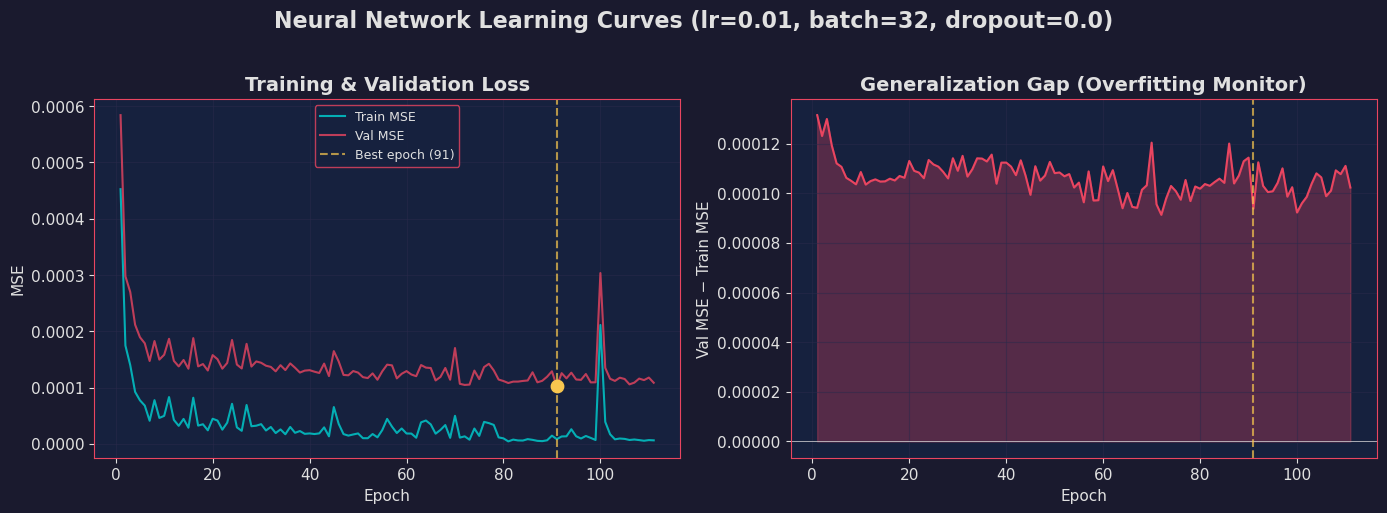

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(best_nn_history["train_mse"]) + 1)
 
# Loss curves
axes[0].plot(epochs, best_nn_history["train_mse"], color=TEAL, linewidth=1.5,
             alpha=0.8, label="Train MSE")
axes[0].plot(epochs, best_nn_history["val_mse"], color=PINK, linewidth=1.5,
             alpha=0.8, label="Val MSE")
best_epoch = np.argmin(best_nn_history["val_mse"]) + 1
best_val = min(best_nn_history["val_mse"])
axes[0].axvline(x=best_epoch, color=GOLD, linestyle="--", alpha=0.7,
                label=f"Best epoch ({best_epoch})")
axes[0].scatter([best_epoch], [best_val], color=GOLD, s=80, zorder=5)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Training & Validation Loss")
axes[0].legend(fontsize=9)
axes[0].grid(True)
 
# Train-val gap
gap = [v - t for t, v in zip(best_nn_history["train_mse"], best_nn_history["val_mse"])]
axes[1].fill_between(epochs, 0, gap, color=PINK, alpha=0.3)
axes[1].plot(epochs, gap, color=PINK, linewidth=1.5)
axes[1].axhline(y=0, color="#e0e0e0", linewidth=0.5)
axes[1].axvline(x=best_epoch, color=GOLD, linestyle="--", alpha=0.7)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val MSE − Train MSE")
axes[1].set_title("Generalization Gap (Overfitting Monitor)")
axes[1].grid(True)
 
config_str = f"lr={best_nn_config['lr']}, batch={best_nn_config['batch_size']}, dropout={best_nn_config['dropout']}"
fig.suptitle(f"Neural Network Learning Curves ({config_str})", y=1.02)
plt.tight_layout()
plt.show()

### 6.5 Neural Network — Test Set Evaluation

In [120]:
print("Neural Network — Final Test Evaluation")
print("=" * 60)
y_test_pred_nn = best_nn_model.predict(X_test)
nn_test = evaluate_model(y_test, y_test_pred_nn, genre_centroids, "Neural Network (best)")

Neural Network — Final Test Evaluation
  Neural Network (best)
    MSE:              0.000255
    Cosine Similarity:0.999216
    Top-3 Accuracy:   0.9782 (97.8%)
    Top-5 Accuracy:   0.9826 (98.3%)


## 7. Model 3: K-Means Clustering

Cluster venues into K archetypes; assign each cluster the mean audio profile
of its member venues. Use elbow method and silhouette score to select K.

This serves as an interpretive tool revealing venue archetypes (per proposal).

In [122]:
class KMeansFromScratch:
    def __init__(self, n_clusters=10, max_iter=300, tol=1e-6, seed=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.seed = seed
        self.centroids = None
        self.labels_ = None
        self.inertia_ = None

    def _kmeans_plus_plus(self, X):
        rng = np.random.RandomState(self.seed)
        n = X.shape[0]
        centroids = [X[rng.randint(n)]]

        for _ in range(1, self.n_clusters):
            # Compute distances to nearest existing centroid
            dists = np.min([np.sum((X - c) ** 2, axis=1) for c in centroids], axis=0)
            probs = dists / dists.sum()
            idx = rng.choice(n, p=probs)
            centroids.append(X[idx])

        return np.array(centroids)

    def fit(self, X):
        self.centroids = self._kmeans_plus_plus(X)

        for iteration in range(self.max_iter):
            # Assignment step
            dists = np.array([np.sum((X - c) ** 2, axis=1) for c in self.centroids]).T
            labels = np.argmin(dists, axis=1)

            # Update step
            new_centroids = np.zeros_like(self.centroids)
            for k in range(self.n_clusters):
                members = X[labels == k]
                if len(members) > 0:
                    new_centroids[k] = members.mean(axis=0)
                else:
                    new_centroids[k] = self.centroids[k]

            # Check convergence
            shift = np.sum((new_centroids - self.centroids) ** 2)
            self.centroids = new_centroids

            if shift < self.tol:
                break

        self.labels_ = labels
        self.inertia_ = sum(np.sum((X[labels == k] - self.centroids[k]) ** 2)
                           for k in range(self.n_clusters))
        return self

    def predict(self, X):
        dists = np.array([np.sum((X - c) ** 2, axis=1) for c in self.centroids]).T
        return np.argmin(dists, axis=1)

print("KMeansFromScratch defined.")

KMeansFromScratch defined.


### 7.1 Silhouette Score (From Scratch)

For each sample:

a = mean distance to other samples in same cluster

b = mean distance to samples in nearest other cluster

s = (b - a) / max(a, b)

In [124]:
def silhouette_score(X, labels):
    n = X.shape[0]
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return 0.0

    scores = np.zeros(n)

    for i in range(n):
        own_cluster = labels[i]
        own_members = X[labels == own_cluster]

        if len(own_members) <= 1:
            scores[i] = 0.0
            continue

        # a(i): mean intra-cluster distance
        a_i = np.mean(np.linalg.norm(own_members - X[i], axis=1))

        # b(i): min mean distance to any other cluster
        b_i = float("inf")
        for k in unique_labels:
            if k == own_cluster:
                continue
            other_members = X[labels == k]
            if len(other_members) == 0:
                continue
            mean_dist = np.mean(np.linalg.norm(other_members - X[i], axis=1))
            b_i = min(b_i, mean_dist)

        scores[i] = (b_i - a_i) / max(a_i, b_i) if max(a_i, b_i) > 0 else 0.0

    return np.mean(scores)

print("silhouette_score defined.")

silhouette_score defined.


### 7.2 Elbow Method & Silhouette: Select K

In [126]:
K_RANGE = range(5, 26, 2)  # Test K = 5, 7, 9, ..., 25

print("K-Means — Elbow & Silhouette Analysis")
print("=" * 55)
print(f"{'K':>4s}  {'Inertia':>12s}  {'Silhouette':>11s}")
print("-" * 55)

# Use a subsample for silhouette (expensive for full data)
rng_sub = np.random.RandomState(SEED)
sil_sample_size = min(1000, X_train.shape[0])
sil_indices = rng_sub.choice(X_train.shape[0], size=sil_sample_size, replace=False)
X_sil_sample = X_train[sil_indices]

kmeans_results = {}
for k in K_RANGE:
    km = KMeansFromScratch(n_clusters=k, max_iter=300, seed=SEED)
    km.fit(X_train)

    # Silhouette on subsample
    labels_sample = km.predict(X_sil_sample)
    sil = silhouette_score(X_sil_sample, labels_sample)

    kmeans_results[k] = {"model": km, "inertia": km.inertia_, "silhouette": sil}
    print(f"{k:4d}  {km.inertia_:12.2f}  {sil:11.4f}")

print("-" * 55)

# Select K with best silhouette
best_k = max(kmeans_results.keys(), key=lambda k: kmeans_results[k]["silhouette"])
print(f"\nBest K by silhouette: {best_k} (score = {kmeans_results[best_k]['silhouette']:.4f})")
best_kmeans = kmeans_results[best_k]["model"]

K-Means — Elbow & Silhouette Analysis
   K       Inertia   Silhouette
-------------------------------------------------------
   5       9984.78       0.0868
   7       9659.91       0.0726
   9       9349.04       0.0752
  11       9006.25       0.0831
  13       8836.90       0.0864
  15       8464.94       0.1038
  17       8396.38       0.0989
  19       8293.91       0.1023
  21       8178.97       0.1095
  23       8128.04       0.1036
  25       7843.30       0.1184
-------------------------------------------------------

Best K by silhouette: 25 (score = 0.1184)


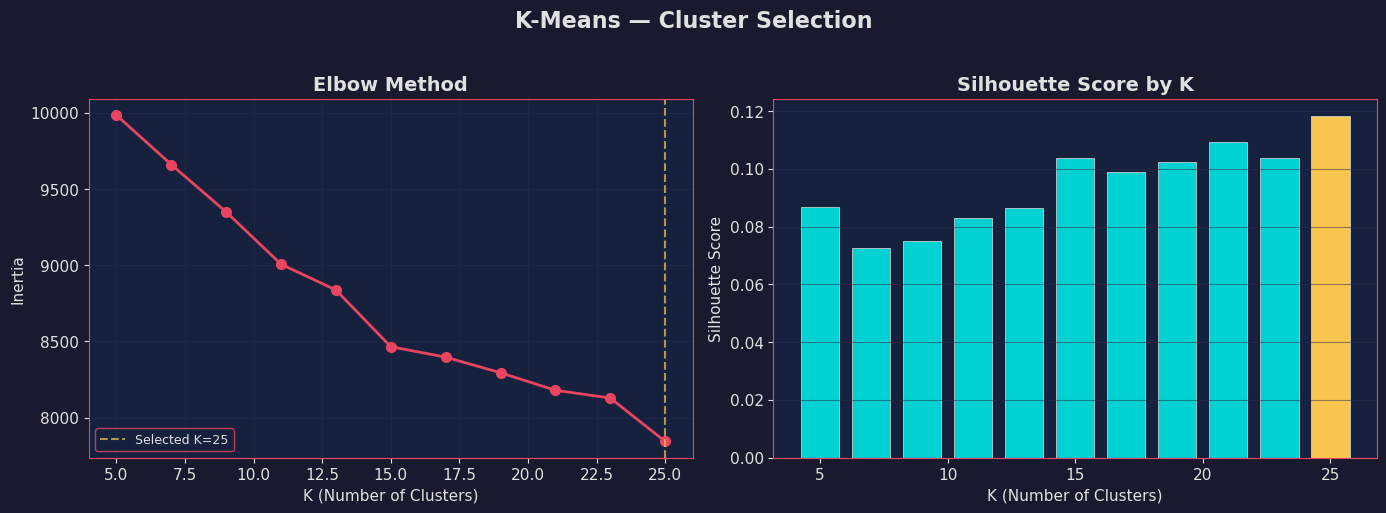

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
ks = sorted(kmeans_results.keys())
inertias = [kmeans_results[k]["inertia"] for k in ks]
silhouettes = [kmeans_results[k]["silhouette"] for k in ks]
 
# Elbow plot
axes[0].plot(ks, inertias, "o-", color=PINK, linewidth=2, markersize=7)
axes[0].axvline(x=best_k, color=GOLD, linestyle="--", alpha=0.7,
                label=f"Selected K={best_k}")
axes[0].set_xlabel("K (Number of Clusters)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")
axes[0].legend(fontsize=9)
axes[0].grid(True)
 
# Silhouette plot
axes[1].bar(ks, silhouettes, color=[GOLD if k == best_k else TEAL for k in ks],
            edgecolor="#e0e0e0", linewidth=0.5, width=1.5)
axes[1].set_xlabel("K (Number of Clusters)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by K")
axes[1].grid(True, axis="y")
 
fig.suptitle("K-Means — Cluster Selection", y=1.02)
plt.tight_layout()
plt.show()

### 7.3 Cluster Audio Profiles

In [129]:
# Assign each cluster a mean audio profile from its training venues
train_labels = best_kmeans.predict(X_train)
cluster_audio_profiles = np.zeros((best_kmeans.n_clusters, y_train.shape[1]))

print(f"Cluster Analysis (K={best_k})")
print("=" * 90)
print(f"{'Cluster':>7s}  {'Size':>5s}  {'Dance':>6s}  {'Energy':>6s}  {'Acous':>6s}  {'Valence':>7s}  {'Instr':>6s}  {'Live':>6s}  {'Speech':>6s}")
print("-" * 90)

for k in range(best_kmeans.n_clusters):
    mask = train_labels == k
    count = mask.sum()
    if count > 0:
        cluster_audio_profiles[k] = y_train[mask].mean(axis=0)
    else:
        cluster_audio_profiles[k] = y_train.mean(axis=0)

    p = cluster_audio_profiles[k]
    print(f"{k:7d}  {count:5d}  {p[0]:.4f}  {p[1]:.4f}  {p[2]:.4f}  {p[3]:.5f}  {p[4]:.4f}  {p[5]:.4f}  {p[6]:.4f}")

print("-" * 90)

Cluster Analysis (K=25)
Cluster   Size   Dance  Energy   Acous  Valence   Instr    Live  Speech
------------------------------------------------------------------------------------------
      0    341  0.6475  0.6296  0.3061  0.46864  0.0827  0.1766  0.0903
      1     74  0.5788  0.4984  0.5014  0.45892  0.0709  0.1671  0.0594
      2    107  0.5874  0.5050  0.4760  0.46074  0.0747  0.1651  0.0628
      3    227  0.6448  0.6668  0.2325  0.48914  0.0590  0.1736  0.0862
      4     51  0.5985  0.5112  0.4712  0.45791  0.0574  0.1622  0.0627
      5     44  0.6133  0.5982  0.3405  0.47542  0.0771  0.1756  0.0766
      6     87  0.5977  0.5129  0.4736  0.45848  0.0710  0.1635  0.0627
      7    144  0.5911  0.4766  0.5273  0.44694  0.0900  0.1671  0.0651
      8     60  0.5739  0.4901  0.5208  0.45490  0.0810  0.1674  0.0582
      9     37  0.5865  0.5030  0.4796  0.45967  0.0753  0.1668  0.0631
     10     39  0.5691  0.5727  0.4030  0.45954  0.1272  0.1952  0.0747
     11     84  0.585

### 7.4 K-Means — Test Set Evaluation

In [131]:
# For prediction: assign test venues to clusters, use cluster audio profiles
test_labels = best_kmeans.predict(X_test)
y_test_pred_km = cluster_audio_profiles[test_labels]

print("K-Means — Final Test Evaluation")
print("=" * 60)
km_test = evaluate_model(y_test, y_test_pred_km, genre_centroids, f"K-Means (K={best_k})")

K-Means — Final Test Evaluation
  K-Means (K=25)
    MSE:              0.001184
    Cosine Similarity:0.996407
    Top-3 Accuracy:   0.8528 (85.3%)
    Top-5 Accuracy:   0.8833 (88.3%)


## 8. Model Comparison & Selection

Three-tier decision from proposal:
1. Primary: Top-K Genre Retrieval Accuracy (margin > 0.03)
2. Secondary: Cosine Similarity
3. Tiebreaker: Ridge (simpler, interpretable, faster)


In [133]:
print("=" * 70)
print("FINAL MODEL COMPARISON — Test Set")
print("=" * 70)
print(f"{'Model':>25s}  {'MSE':>10s}  {'CosSim':>8s}  {'Acc@3':>7s}  {'Acc@5':>7s}")
print("-" * 70)

models_summary = {
    f"Ridge (λ={best_ridge_lambda})": ridge_test,
    "Neural Network (best)": nn_test,
    f"K-Means (K={best_k})": km_test,
    "Mean Baseline": baseline_mean,
}

for name, metrics in models_summary.items():
    print(f"{name:>25s}  {metrics['mse']:10.6f}  {metrics['cosine_sim']:8.6f}  "
          f"{metrics['top3_acc']:7.4f}  {metrics['top5_acc']:7.4f}")

print("-" * 70)

ridge_acc5 = ridge_test["top5_acc"]
nn_acc5 = nn_test["top5_acc"]
km_acc5 = km_test["top5_acc"]

MARGIN = 0.03

print("\n── Model Selection ──")

# Primary criterion: Top-5 accuracy
if nn_acc5 - ridge_acc5 > MARGIN:
    selected = "Neural Network"
    reason = f"NN Acc@5 ({nn_acc5:.4f}) exceeds Ridge ({ridge_acc5:.4f}) by > {MARGIN}"
elif ridge_acc5 - nn_acc5 > MARGIN:
    selected = "Ridge"
    reason = f"Ridge Acc@5 ({ridge_acc5:.4f}) exceeds NN ({nn_acc5:.4f}) by > {MARGIN}"
else:
    # Secondary: Cosine similarity
    print(f"  Acc@5 within margin ({abs(nn_acc5 - ridge_acc5):.4f} < {MARGIN}). Checking cosine similarity...")
    if nn_test["cosine_sim"] > ridge_test["cosine_sim"] + 0.005:
        selected = "Neural Network"
        reason = f"NN CosSim ({nn_test['cosine_sim']:.6f}) > Ridge ({ridge_test['cosine_sim']:.6f})"
    elif ridge_test["cosine_sim"] > nn_test["cosine_sim"] + 0.005:
        selected = "Ridge"
        reason = f"Ridge CosSim ({ridge_test['cosine_sim']:.6f}) > NN ({nn_test['cosine_sim']:.6f})"
    else:
        # Tiebreaker: Ridge (simpler)
        selected = "Ridge"
        reason = "Practical tiebreaker: Ridge is simpler, faster, and interpretable"

print(f"  Selected: {selected}")
print(f"  Reason: {reason}")
print(f"\nK-Means serves as interpretive tool (venue archetypes) — not a deployment candidate.")

FINAL MODEL COMPARISON — Test Set
                    Model         MSE    CosSim    Acc@3    Acc@5
----------------------------------------------------------------------
            Ridge (λ=0.1)    0.000281  0.999140   0.9804   0.9858
    Neural Network (best)    0.000255  0.999216   0.9782   0.9826
           K-Means (K=25)    0.001184  0.996407   0.8528   0.8833
            Mean Baseline    0.004124  0.987393   0.2923   0.3631
----------------------------------------------------------------------

── Model Selection ──
  Acc@5 within margin (0.0033 < 0.03). Checking cosine similarity...
  Selected: Ridge
  Reason: Practical tiebreaker: Ridge is simpler, faster, and interpretable

K-Means serves as interpretive tool (venue archetypes) — not a deployment candidate.


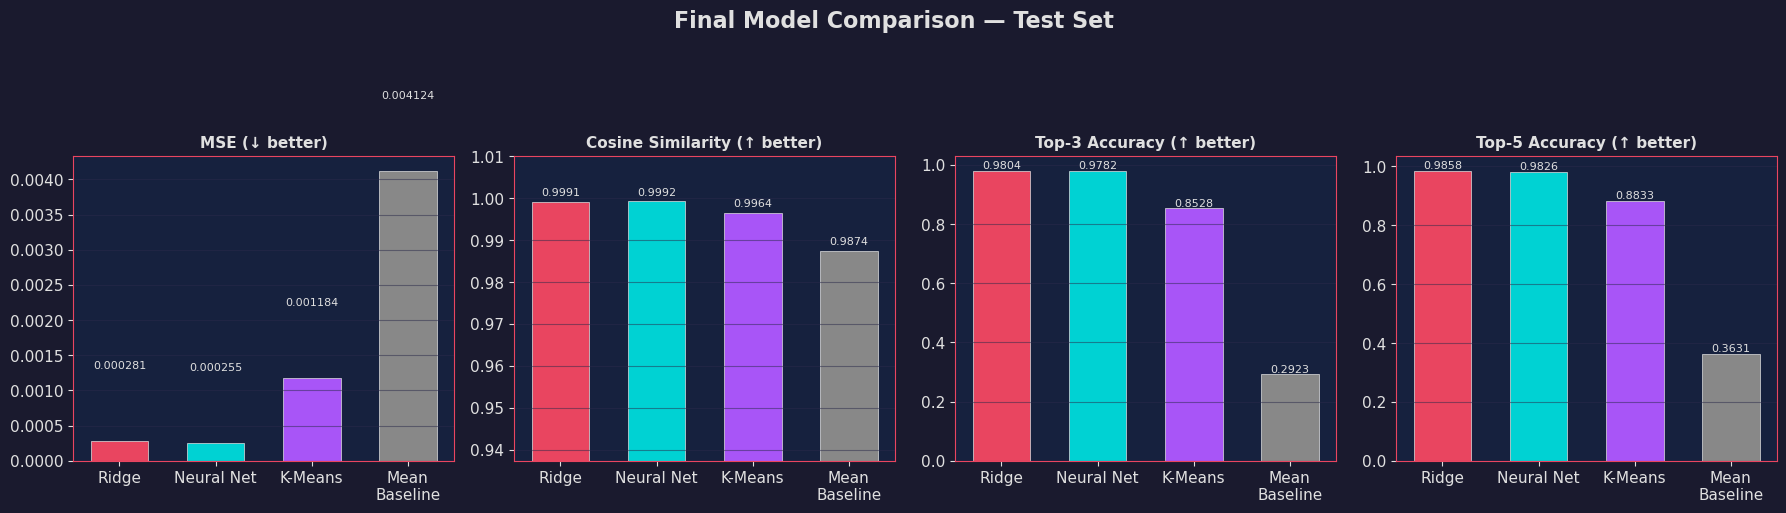

In [134]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
 
model_names = ["Ridge", "Neural Net", "K-Means", "Mean\nBaseline"]
model_colors = [PINK, TEAL, PURPLE, GRAY]
model_metrics = [ridge_test, nn_test, km_test, baseline_mean]
 
metrics_to_plot = [
    ("mse", "MSE (↓ better)", False),
    ("cosine_sim", "Cosine Similarity (↑ better)", True),
    ("top3_acc", "Top-3 Accuracy (↑ better)", True),
    ("top5_acc", "Top-5 Accuracy (↑ better)", True),
]
 
for ax, (key, title, higher_better) in zip(axes, metrics_to_plot):
    values = [m[key] for m in model_metrics]
    bars = ax.bar(model_names, values, color=model_colors,
                  edgecolor="#e0e0e0", linewidth=0.5, width=0.6)
 
    for bar, val in zip(bars, values):
        fmt = f"{val:.6f}" if key == "mse" else f"{val:.4f}"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                fmt, ha="center", va="bottom", fontsize=8, color="#e0e0e0")
 
    ax.set_title(title, fontsize=11)
    ax.grid(True, axis="y")
 
    # Tighten y-axis for near-1.0 metrics
    if higher_better and min(values) > 0.8:
        ax.set_ylim(min(values) - 0.05, 1.01)
 
fig.suptitle("Final Model Comparison — Test Set", y=1.02)
plt.tight_layout()
plt.show()

## 9. Per-Dimension MSE Analysis

In [136]:
print("Per-Dimension MSE on Test Set")
print("=" * 65)
print(f"{'Feature':>20s}  {'Ridge':>10s}  {'NN':>10s}  {'K-Means':>10s}")
print("-" * 65)

for j, feat in enumerate(AUDIO_FEATURES):
    r_mse = np.mean((y_test[:, j] - y_test_pred_ridge[:, j]) ** 2)
    n_mse = np.mean((y_test[:, j] - y_test_pred_nn[:, j]) ** 2)
    k_mse = np.mean((y_test[:, j] - y_test_pred_km[:, j]) ** 2)
    print(f"{feat:>20s}  {r_mse:10.6f}  {n_mse:10.6f}  {k_mse:10.6f}")

print("-" * 65)

Per-Dimension MSE on Test Set
             Feature       Ridge          NN     K-Means
-----------------------------------------------------------------
        danceability    0.000074    0.000068    0.000637
              energy    0.000525    0.000469    0.002041
        acousticness    0.000900    0.000840    0.003638
             valence    0.000045    0.000041    0.000280
    instrumentalness    0.000364    0.000312    0.001511
            liveness    0.000048    0.000041    0.000150
         speechiness    0.000009    0.000012    0.000030
-----------------------------------------------------------------


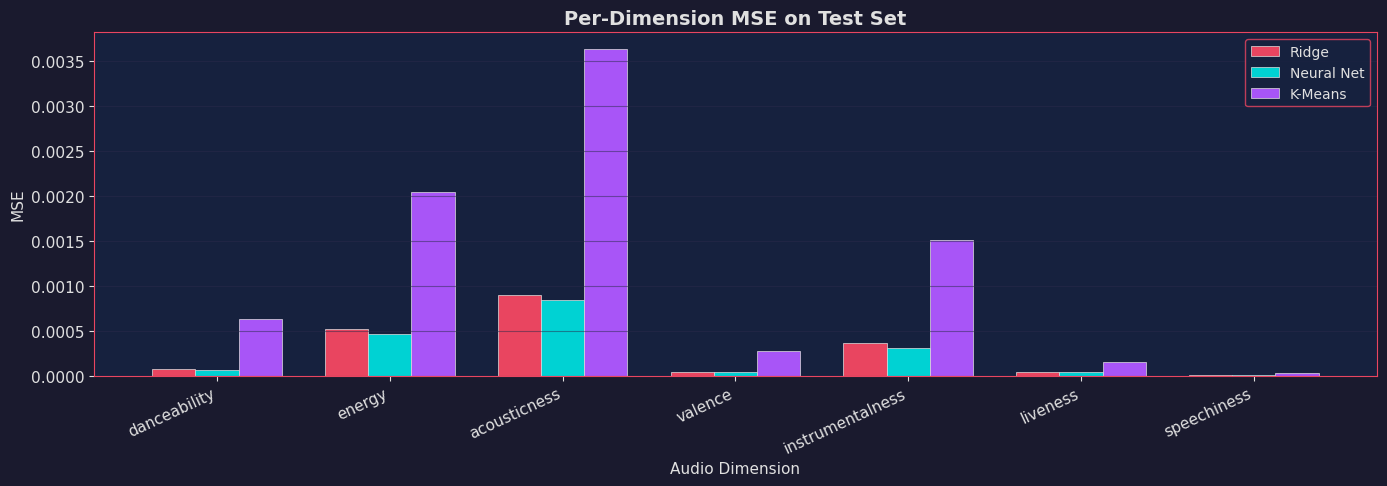

In [137]:
fig, ax = plt.subplots(figsize=(14, 5))
 
x = np.arange(len(AUDIO_FEATURES))
width = 0.25
 
ridge_dim_mse = [np.mean((y_test[:, j] - y_test_pred_ridge[:, j]) ** 2) for j in range(7)]
nn_dim_mse = [np.mean((y_test[:, j] - y_test_pred_nn[:, j]) ** 2) for j in range(7)]
km_dim_mse = [np.mean((y_test[:, j] - y_test_pred_km[:, j]) ** 2) for j in range(7)]
 
bars1 = ax.bar(x - width, ridge_dim_mse, width, label="Ridge", color=PINK,
               edgecolor="#e0e0e0", linewidth=0.5)
bars2 = ax.bar(x, nn_dim_mse, width, label="Neural Net", color=TEAL,
               edgecolor="#e0e0e0", linewidth=0.5)
bars3 = ax.bar(x + width, km_dim_mse, width, label="K-Means", color=PURPLE,
               edgecolor="#e0e0e0", linewidth=0.5)
 
ax.set_xlabel("Audio Dimension")
ax.set_ylabel("MSE")
ax.set_title("Per-Dimension MSE on Test Set")
ax.set_xticks(x)
ax.set_xticklabels(AUDIO_FEATURES, rotation=25, ha="right")
ax.legend(fontsize=10)
ax.grid(True, axis="y")
 
plt.tight_layout()
plt.show()

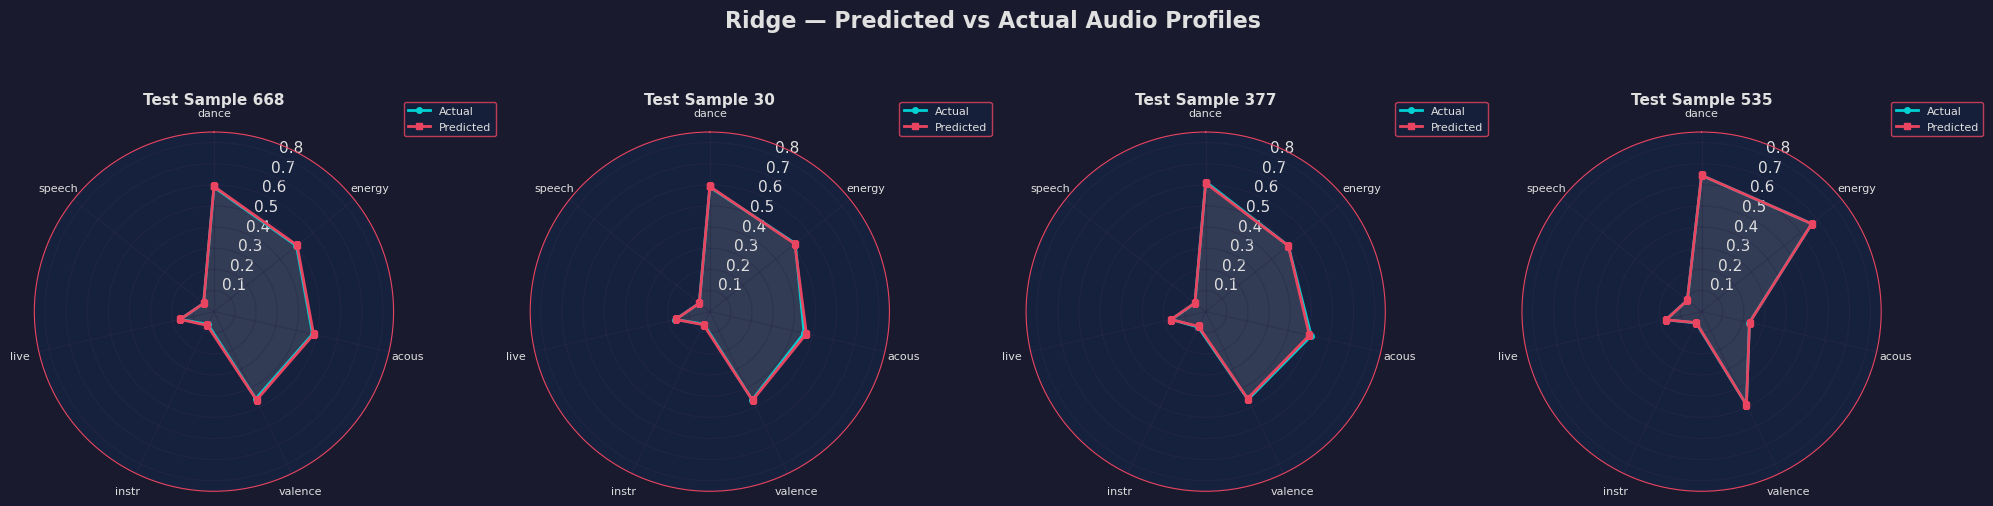

In [138]:
def radar_chart(ax, actual, predicted, labels, title):
    #Draws a radar/spider chart comparing actual vs predicted profiles
    n = len(labels)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]  # close the polygon
 
    actual = list(actual) + [actual[0]]
    predicted = list(predicted) + [predicted[0]]
 
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=8, color="#e0e0e0")
 
    ax.plot(angles, actual, "o-", color=TEAL, linewidth=2, markersize=4, label="Actual")
    ax.fill(angles, actual, color=TEAL, alpha=0.15)
    ax.plot(angles, predicted, "s-", color=PINK, linewidth=2, markersize=4, label="Predicted")
    ax.fill(angles, predicted, color=PINK, alpha=0.15)
 
    ax.set_ylim(0, 0.85)
    ax.set_title(title, fontsize=11, pad=20, color="#e0e0e0")
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=8)
    ax.grid(color="#2a2a4a")
    ax.set_facecolor("#16213e")
 
 
# Pick 4 diverse test samples
rng_viz = np.random.RandomState(SEED)
sample_idx = rng_viz.choice(len(y_test), size=4, replace=False)
 
fig, axes = plt.subplots(1, 4, figsize=(20, 5), subplot_kw={"projection": "polar"})
fig.patch.set_facecolor("#1a1a2e")
 
short_labels = ["dance", "energy", "acous", "valence", "instr", "live", "speech"]
 
for i, (ax, idx) in enumerate(zip(axes, sample_idx)):
    radar_chart(
        ax,
        actual=y_test[idx],
        predicted=y_test_pred_ridge[idx],
        labels=short_labels,
        title=f"Test Sample {idx}"
    )
 
fig.suptitle("Ridge — Predicted vs Actual Audio Profiles", y=1.05, color="#e0e0e0")
plt.tight_layout()
plt.show()

## 10. Save Trained Models

In [140]:
os.makedirs("pipeline_artifacts", exist_ok=True)

# Save Ridge model
ridge_artifact = {
    "W": best_ridge_model.W,
    "alpha": best_ridge_lambda,
    "feature_names": feature_names,
    "audio_features": AUDIO_FEATURES,
}
with open("pipeline_artifacts/ridge_model.pkl", "wb") as f:
    pickle.dump(ridge_artifact, f)
print("Saved: pipeline_artifacts/ridge_model.pkl")

# Save Neural Network weights
nn_weights = best_nn_model._save_weights()
nn_artifact = {
    "weights": nn_weights,
    "config": {
        "input_dim": X_train.shape[1],
        "hidden1": 128 if not hasattr(best_nn_model, '_wide') else 256,
        "hidden2": 64 if not hasattr(best_nn_model, '_wide') else 128,
        "output_dim": 7,
        "lr": best_nn_config["lr"],
        "dropout_rate": best_nn_config["dropout"],
        "use_batch_norm": best_nn_model.use_batch_norm,
    },
    "feature_names": feature_names,
    "audio_features": AUDIO_FEATURES,
}
with open("pipeline_artifacts/nn_model.pkl", "wb") as f:
    pickle.dump(nn_artifact, f)
print("Saved: pipeline_artifacts/nn_model.pkl")

# Save K-Means
kmeans_artifact = {
    "centroids": best_kmeans.centroids,
    "n_clusters": best_kmeans.n_clusters,
    "cluster_audio_profiles": cluster_audio_profiles,
    "feature_names": feature_names,
    "audio_features": AUDIO_FEATURES,
}
with open("pipeline_artifacts/kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans_artifact, f)
print("Saved: pipeline_artifacts/kmeans_model.pkl")

# Save all test results for comparison
results_summary = {
    "ridge": ridge_test,
    "nn": nn_test,
    "kmeans": km_test,
    "baseline_mean": baseline_mean,
    "baseline_random": baseline_rand,
    "selected_model": selected,
    "selection_reason": reason,
    "ridge_lambda": best_ridge_lambda,
    "nn_config": {k: v for k, v in best_nn_config.items() if k not in ["model", "history"]},
    "kmeans_k": best_k,
    "ablation_results": ablation_results,
}
with open("pipeline_artifacts/evaluation_results.pkl", "wb") as f:
    pickle.dump(results_summary, f)
print("Saved: pipeline_artifacts/evaluation_results.pkl")
print(f"\nDone. Selected model for deployment: {selected}")

Saved: pipeline_artifacts/ridge_model.pkl
Saved: pipeline_artifacts/nn_model.pkl
Saved: pipeline_artifacts/kmeans_model.pkl
Saved: pipeline_artifacts/evaluation_results.pkl

Done. Selected model for deployment: Ridge


## Handoff Notes

### For Streamlit Deployment

```python
import pickle
import numpy as np

# Load Ridge model
with open("pipeline_artifacts/ridge_model.pkl", "rb") as f:
    ridge = pickle.load(f)

W = ridge["W"]  # (d+1, 7) — includes bias row

# Predict: add bias column, then matrix multiply
def predict_ridge(X):
    X_b = np.hstack([X, np.ones((X.shape[0], 1))])
    return X_b @ W
```

### For Neural Network Deployment

```python
# Load NN model
with open("pipeline_artifacts/nn_model.pkl", "rb") as f:
    nn_data = pickle.load(f)

# Reconstruct NN class and load weights
model = NeuralNetwork(**nn_data["config"])
model._load_weights(nn_data["weights"])
y_pred = model.predict(X_new)
```

### For Playlist Generation

```python
# After getting predicted audio profile y_pred (shape: (1, 7)):
# 1. Find K nearest genre centroids
dists = np.linalg.norm(genre_centroids - y_pred, axis=1)
top_k_genres = np.argsort(dists)[:5]

# 2. Sample songs from those genres, weighted by popularity
# 3. Display as playlist
```
